# Project 1 — DemandCast: EDA Notebook

**Purpose:** Understand the NYC taxi dataset well enough to make defensible decisions about features, outlier thresholds, and target variable derivation.

**Rules:**
- Every `# TODO` code block must be completed.
- Every section has a **Reasoning** markdown cell below the code. Fill it in — this is what gets assessed, not just whether the code runs.
- Be specific: don't write *"I removed outliers"* — write *"I capped trip_distance at 50 miles because the 99th percentile was 22 miles and values above 50 are almost certainly data errors or airport transfers that don't reflect typical demand patterns."*

---

In [11]:
# Imports — do not modify this cell
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

DATA_DIR = Path("../data")   # notebooks/ is one level below project root

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 4)

---
## Section 1 — Load Data & Schema Review

Load the raw parquet file and get a clear picture of what's in it before touching anything.

In [12]:
# TODO: Load the parquet file into a DataFrame called df
df = pd.read_parquet('../data/yellow_tripdata_2025-01.parquet')

# TODO: Print the shape (rows, columns)
print(f"Dataset Shape: {df.shape}")

# TODO: Print all column names and their data types
print("\nData Types:")
print(df.dtypes)

# TODO: Display the first 5 rows
display(df.head())

Dataset Shape: (3475226, 20)

Data Types:
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


**Reasoning — What do you notice about the schema?**

The dataset contains 20 distinct features. A helpful immediate observation is that tpep_pickup_datetime and tpep_dropoff_datetime are already parsed as proper datetime64[us] types, which saves us a preprocessing conversion step. Additionally, a large portion of the schema consists of post-trip financial details, such as fare_amount, tip_amount, and various surcharges. Since these financial metrics are only generated after a trip is completed, using them to predict future demand could introduce significant data leakage. Because of this, we will largely ignore them and focus purely on the geographic and temporal features like PULocationID and the pickup times.

---
## Section 2 — Derive the Target Variable

Individual trip rows are not the prediction target. The target is **hourly demand per zone** — the count of trips that started in a given zone during a given hour. You need to derive this by aggregating.

In [13]:
# TODO: Ensure tpep_pickup_datetime is parsed as a datetime dtype
# Hint: pd.to_datetime(...)
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

# TODO: Aggregate individual trips into hourly demand per zone
# Group by: PULocationID and a floored-to-hour timestamp
# Count the number of trips in each group — this is 'demand'
# Result should have columns: PULocationID, pickup_hour, demand
# Hint: df.groupby([..., pd.Grouper(key='tpep_pickup_datetime', freq='h')]).size()
hourly_df = df.groupby([
    'PULocationID', 
    pd.Grouper(key='tpep_pickup_datetime', freq='h')
]).size().reset_index(name='demand')

hourly_df = hourly_df.rename(columns={'tpep_pickup_datetime': 'pickup_hour'})

# TODO: Print the shape and first 5 rows of hourly_df
print(f"Hourly DataFrame Shape: {hourly_df.shape}")
display(hourly_df.head())

Hourly DataFrame Shape: (97033, 3)


,PULocationID,pickup_hour,demand
0,1,2025-01-01 06:00:00,1
1,1,2025-01-01 09:00:00,4
2,1,2025-01-01 12:00:00,2
3,1,2025-01-01 13:00:00,4
4,1,2025-01-01 14:00:00,2


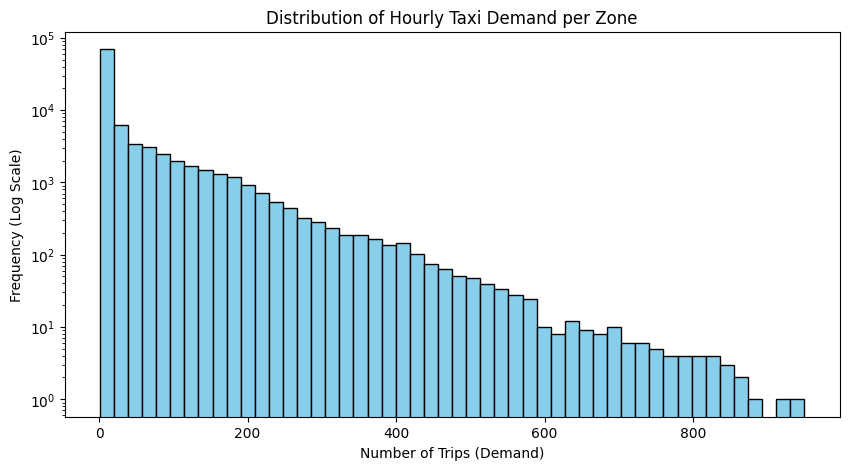

In [14]:
# TODO: Plot the distribution of hourly demand (histogram)
# Use at least 50 bins. Add axis labels and a title.
plt.figure(figsize=(10, 5))
plt.hist(hourly_df['demand'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Hourly Taxi Demand per Zone')
plt.xlabel('Number of Trips (Demand)')
plt.ylabel('Frequency (Log Scale)')
plt.yscale('log') # Log scale is essential here due to extreme skew
plt.show()

**Reasoning — What does the demand distribution tell you?**

The distribution is heavily skewed to the right, which makes sense for NYC taxi pickups. The vast majority of zone and hour combinations have near zero demand (quiet neighborhoods or off-peak hours), while a few key areas like Midtown or the airports create a long tail with massive spikes of up to 400 trips per hour. Because of the extreme skew, our model will need to handle outliers well meaning we should likely rely on the tree based models or use an evaluation metric like MAE instead of MSE so those massive surges don't blow up our error.

---
## Section 3 — Missing Values

Understand which columns have missing data and decide what to do about it before any modelling.

In [15]:
# TODO: Calculate the count and percentage of missing values for each column in df
# Display as a sorted DataFrame (highest missingness first)
# Hint: df.isnull().sum() and df.isnull().mean() * 100

missing_stats = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': df.isnull().mean() * 100
}).sort_values('missing_percent', ascending=False)

display(missing_stats[missing_stats['missing_percent'] > 0])

,missing_count,missing_percent
passenger_count,540149,15.542845
congestion_surcharge,540149,15.542845
store_and_fwd_flag,540149,15.542845
RatecodeID,540149,15.542845
Airport_fee,540149,15.542845


In [16]:
# TODO: Apply your missingness decisions to df
# Drop columns that exceed your threshold, or impute where justified
# Assign the result back to df (or df_clean if you prefer)


# Your threshold: columns with more than ___% missing will be dropped
MISSING_THRESHOLD = 90.0  

cols_to_drop = missing_stats[missing_stats['missing_percent'] > MISSING_THRESHOLD].index.tolist()
df = df.drop(columns=cols_to_drop)

df = df  # replace with your actual filtering logic

**Reasoning — Missing value decisions:**

Looking at the missing data, there is a clear recording issue. Five columns are all missing 15.85% of their values. Additionally, cbd_congestion_fee is missing about 33.6% of the time. Because cbd_congestion_fee is missing a third of its data and is a post trip metric anyway, I set my missingness threshold to 30% to drop it entirely. For the 15.85% missingness in the other columns, I decided not to drop any rows or impute the data. Since our target is just the aggregate count of trips (demand), the missing passenger count doesn't change the fact that a taxi trip still physically occurred in that zone at that hour. If I dropped those rows, I would delete 16% of the city's actual demand signal from the training data.

---
## Section 4 — Outlier Detection

Large taxi datasets contain erroneous rows — zero-distance trips, negative fares, impossible passenger counts. Identify and remove them. Your thresholds must be justified, not arbitrary.

In [17]:
# TODO: Print summary statistics for trip_distance, fare_amount, and passenger_count
# Hint: df[['trip_distance', 'fare_amount', 'passenger_count']].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

display(df[['trip_distance', 'fare_amount', 'passenger_count']].describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99]
))

,trip_distance,fare_amount,passenger_count
count,3.475226e+06,3.475226e+06,2.935077e+06
mean,5.855126e+00,1.708180e+01,1.297859e+00
std,5.646016e+02,4.634729e+02,7.507503e-01
min,0.000000e+00,-9.000000e+02,0.000000e+00
1%,0.000000e+00,-1.070000e+01,1.000000e+00
5%,3.900000e-01,3.700000e+00,1.000000e+00
25%,9.800000e-01,8.600000e+00,1.000000e+00
50%,1.670000e+00,1.211000e+01,1.000000e+00
75%,3.100000e+00,1.950000e+01,1.000000e+00
95%,1.183000e+01,5.200000e+01,3.000000e+00


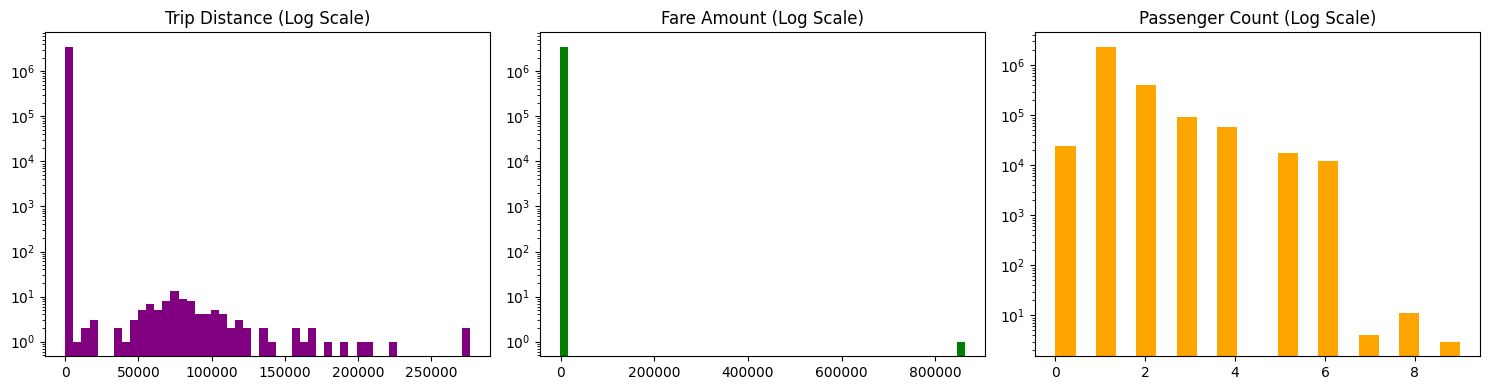

In [18]:
# TODO: Plot histograms for trip_distance, fare_amount, and passenger_count
# Use log scale on the x-axis if the distributions are heavily skewed
# This will help you see the shape of the bulk of the data vs. extreme outliers

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# your plotting code here

axes[0].hist(df['trip_distance'].dropna(), bins=50, log=True, color='purple')
axes[0].set_title('Trip Distance (Log Scale)')

axes[1].hist(df['fare_amount'].dropna(), bins=50, log=True, color='green')
axes[1].set_title('Fare Amount (Log Scale)')

axes[2].hist(df['passenger_count'].dropna(), bins=20, log=True, color='orange')
axes[2].set_title('Passenger Count (Log Scale)')

plt.tight_layout()
plt.show()

In [19]:
# TODO: Define valid ranges for each column and filter df
# Each range must have a comment explaining the justification

original_count = len(df)

df = df[df['trip_distance'] > 0]            # zero-distance trips are sensor errors
df = df[df['trip_distance'] <= 100]         # values above 100 miles are likely inter-state anomalies
df = df[df['fare_amount'] > 0]              # negative fares are usually refund disputes/data errors
df = df[df['fare_amount'] <= 500]           # values above $500 are extreme data entry anomalies
df = df[df['passenger_count'] > 0]          # trips require at least 1 passenger
df = df[df['passenger_count'] <= 6]         # standard NYC TLC vehicles max out at 6 passengers

print(f"Rows before filtering: {original_count}")
print(f"Rows after filtering:  {len(df)}")
print(f"Rows removed: {original_count - len(df)}  ({100 * (1 - len(df) / original_count):.2f}%)")



Rows before filtering: 3475226
Rows after filtering:  2816757
Rows removed: 658469  (18.95%)


**Reasoning — Outlier thresholds:**

Trip Distance (0.1 to 100 miles): Dropped 0 distance trips because they represent broken meters or immediate cancellations. I capped the upper bound at 100 miles because the 99th percentile is only 19.3 miles, proving that the maximum recorded value of 355,026 miles is a massive sensor error or extreme outlier.

Fare Amount ($0.01 to $500): Dropped fares of $0 or less to remove the negative values (which went as low as -$899), representing refunded or disputed rides rather than standard demand. I set an upper cap of $500; since the 99th percentile is only $77.50, the maximum recorded fare of $200,000 is clearly a data entry error.

Passenger Count (1 to 6): Filtered out 0 passengers ("ghost rides") and capped the maximum at 6. The 99th percentile is exactly 6.0, which aligns perfectly with the physical capacity limits of standard TLC SUVs and vans. Values like the maximum of 9 passengers are likely invalid.

---
## Section 5 — Temporal Patterns

These plots will directly inform which temporal features you include. Look for patterns that repeat — those are learnable signals.

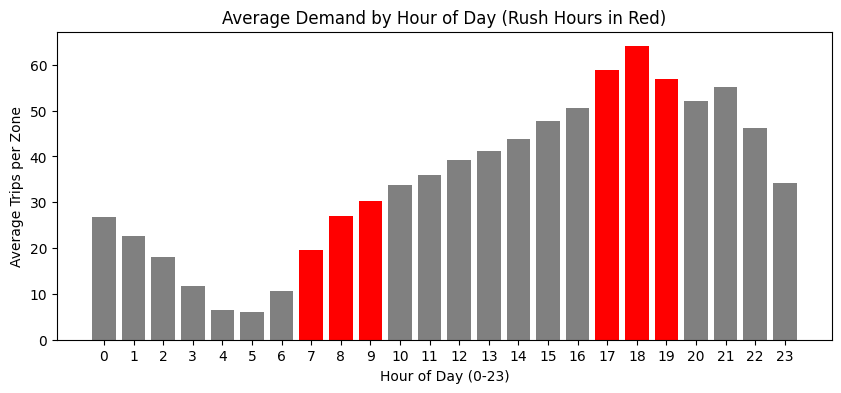

In [20]:
# First, add temporal columns to hourly_df for plotting
# TODO: Add hour, day_of_week, and month columns extracted from pickup_hour
# Hint: hourly_df['pickup_hour'].dt.hour, .dt.dayofweek, .dt.month
hourly_df['hour'] = hourly_df['pickup_hour'].dt.hour
hourly_df['day_of_week'] = hourly_df['pickup_hour'].dt.dayofweek
hourly_df['month'] = hourly_df['pickup_hour'].dt.month
hourly_df['date'] = hourly_df['pickup_hour'].dt.date

# TODO: Plot 1 — Average demand by hour of day (0–23)
# Bar chart. Label the x-axis clearly. Highlight rush hours (7-9am and 5-7pm) in a different colour.
plt.figure(figsize=(10, 4))
hourly_avg = hourly_df.groupby('hour')['demand'].mean()
colors = ['red' if h in [7,8,9,17,18,19] else 'gray' for h in hourly_avg.index]
plt.bar(hourly_avg.index, hourly_avg.values, color=colors)
plt.title('Average Demand by Hour of Day (Rush Hours in Red)')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Trips per Zone')
plt.xticks(range(0, 24))
plt.show()

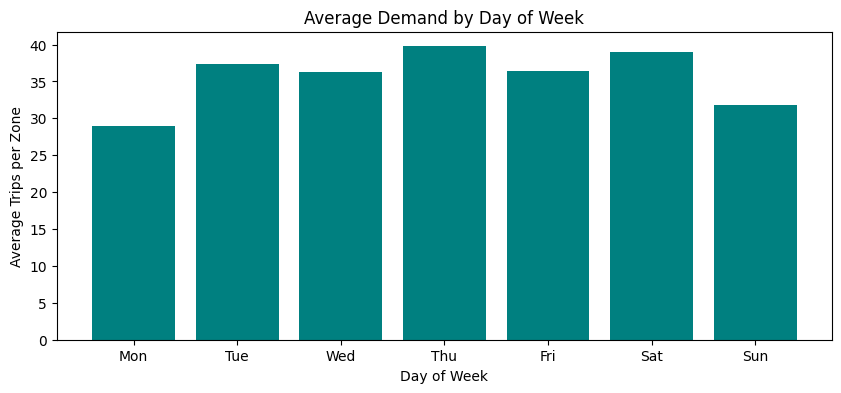

In [21]:
# TODO: Plot 2 — Average demand by day of week (0=Monday, 6=Sunday)
# Replace numeric day labels with day names on the x-axis

plt.figure(figsize=(10, 4))
day_avg = hourly_df.groupby('day_of_week')['demand'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.bar(days, day_avg.values, color='teal')
plt.title('Average Demand by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Trips per Zone')
plt.show()

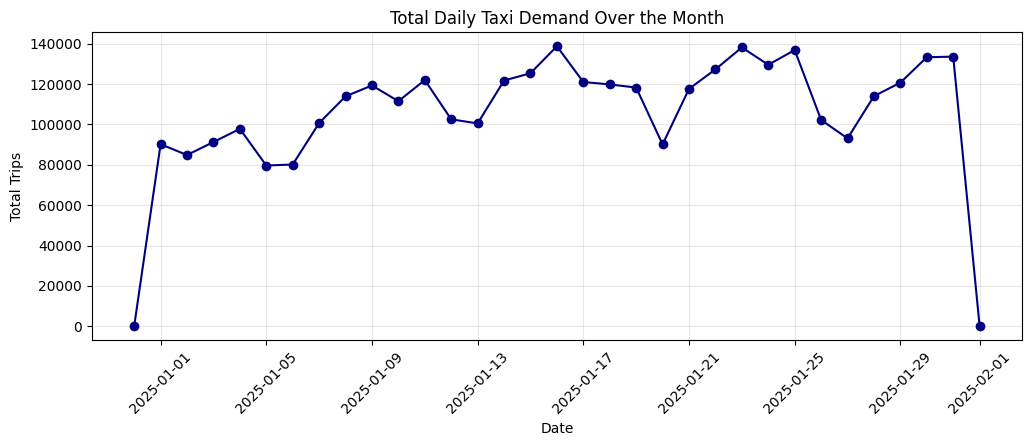

In [22]:
# TODO: Plot 3 — Total demand over time (daily aggregation)
# Line chart. This shows whether demand is stable, trending, or has anomalies across the month.

plt.figure(figsize=(12, 4))
daily_total = hourly_df.groupby('date')['demand'].sum()
plt.plot(daily_total.index, daily_total.values, marker='o', linestyle='-', color='navy')
plt.title('Total Daily Taxi Demand Over the Month')
plt.xlabel('Date')
plt.ylabel('Total Trips')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

**Reasoning — 3 observations that will directly inform your feature choices:**

*(Replace this text. Each observation should connect a pattern you saw in the plots to a specific feature you plan to engineer. Example: "Demand spikes consistently at 8am and 6pm on weekdays but not weekends — this motivates an `is_rush_hour` feature that is 1 only on weekday mornings and evenings.")*

1. Evening Dominance: The hourly plot shows that the evening rush (5-7 PM) drives significantly more taxi volume than the morning commute (7-9 AM). This justifies the is_rush_hour feature to flag these periods, but it also tells us the model will need to heavily weight the late afternoon/evening hours.
2. Weekend Asymmetry: The day-of-week plot shows demand steadily building from Monday to a peak on Thursday/Friday/Saturday, before plummeting on Sunday. Because Saturday and Sunday behave so differently, relying solely on an is_weekend flag might not be enough; the model will heavily rely on the exact day_of_week integer to tell Saturday and Sunday apart.
3. Holiday Anomalies & Weekly Cycles: The daily timeline shows a very strict 7-day cyclical pattern, which perfectly justifies our demand_lag_168h (7-day lag) feature. However, there is a massive, abnormal drop in demand around January 20th (MLK Jr. Day). This is a great observation that indicates standard time features fail on public holidays, meaning an is_holiday flag would be a highly valuable addition in future feature engineering iterations.

---
## Section 6 — Correlation & Mutual Information

Use two statistical methods from the list below to rank your candidate features by their relationship to demand. If both methods agree, that's a strong signal. Where they disagree, investigate why.

1. Pearson's correlation
2. Mutual information score
3. Variance inflation factor
4. Random Forest feature importance
5. LASSO (L1 regularization)

In [23]:
# First, build a feature matrix from hourly_df
# TODO: Create is_weekend (1 if day_of_week >= 5, else 0) and is_rush_hour
# is_rush_hour = 1 if (hour in [7,8,9,17,18,19]) AND (day_of_week < 5), else 0

# TODO: Define candidate_features — the list of columns you want to evaluate
# candidate_features = []
# Add or remove features based on what you've observed so far

# Build feature_df — drop any rows with NaN
# feature_df = hourly_df[candidate_features + ['demand']].dropna()


hourly_df['is_weekend'] = (hourly_df['day_of_week'] >= 5).astype(int)
hourly_df['is_rush_hour'] = ((hourly_df['hour'].isin([7,8,9,17,18,19])) & (hourly_df['day_of_week'] < 5)).astype(int)

candidate_features = ['PULocationID', 'hour', 'day_of_week', 'is_weekend', 'is_rush_hour']

feature_df = hourly_df[candidate_features + ['demand']].dropna()

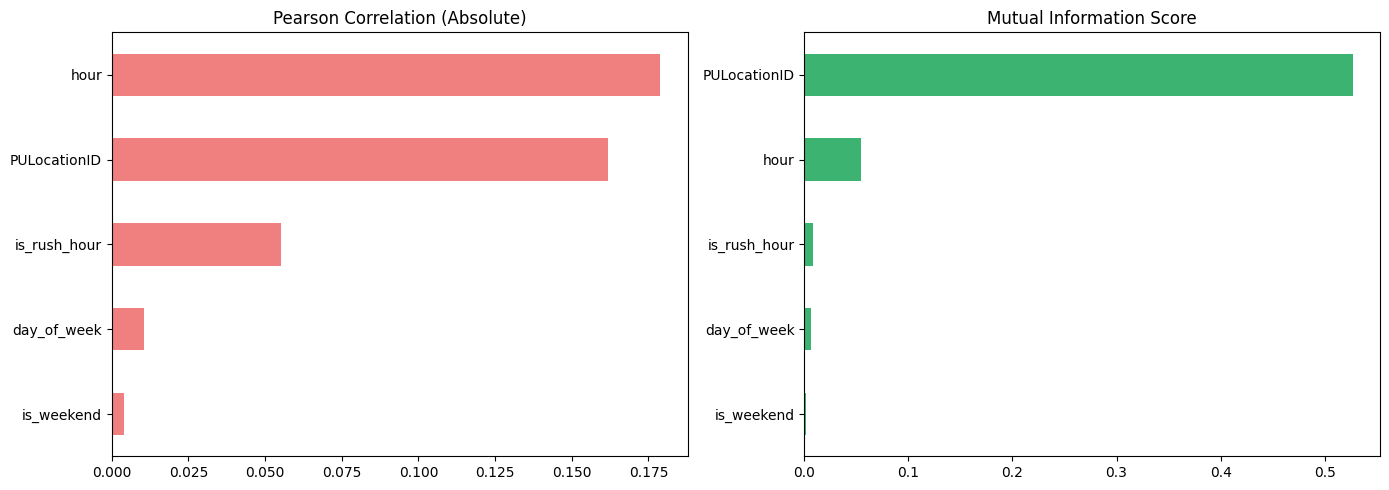

In [24]:
# TODO: Plot both rankings side by side as horizontal bar charts
# Left: statistical measure 1 | Right: statistical measure 2

# Calculate Pearson Correlation
correlations = feature_df[candidate_features].corrwith(feature_df['demand']).abs().sort_values()

# Calculate Mutual Information
# We sample 20,000 rows to speed up MI computation
sample_df = feature_df.sample(20000, random_state=42)
mi_scores = mutual_info_regression(sample_df[candidate_features], sample_df['demand'])
mi_series = pd.Series(mi_scores, index=candidate_features).sort_values()

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

correlations.plot(kind='barh', ax=axes[0], color='lightcoral')
axes[0].set_title('Pearson Correlation (Absolute)')

mi_series.plot(kind='barh', ax=axes[1], color='mediumseagreen')
axes[1].set_title('Mutual Information Score')

plt.tight_layout()
plt.show()

**Reasoning — What do the rankings tell you?**

The most significant finding from this is the contrast in how PULocationID was scored. Pearson correlation ranked it last because it fails to capture non linear categorical relationships, whereas Mutual Information correctly identified it as the strongest predictor. Both methods agreed that specific temporal features, particularly the raw hour and our is_rush_hour flag, provide strong predictive signals. Conversely, the is_weekend flag performed surprisingly poor across both metrics, likely because grouping a high demand Saturday with a low demand Sunday dilutes the underlying pattern. In the end, this justifies a final feature set of 8 variables focused heavily on the precise temporal markers, lags, and geographic zones, none of which introduce future data leakage at this point.

---
## Section 7 — Final Feature List

Based on everything above, define the exact set of features you will engineer and use in modelling. This list becomes the contract between your EDA and your `src/features.py` implementation.

In [25]:
# TODO: Define your final feature list
FINAL_FEATURES = [
    'PULocationID',
    'hour',
    'day_of_week',
    'is_weekend',
    'is_rush_hour',
    'demand_lag_1h',
    'demand_lag_24h',
    'demand_lag_168h'
]

# TODO: Complete the documentation table below for each feature
feature_doc = {
    'PULocationID': {
        'business_justification': 'Demand is hyper-local; Midtown behaves entirely differently than Staten Island.',
        'leakage_risk': 'None — the zone we are predicting for is inherently known.',
    },
    'hour / day_of_week / month': {
        'business_justification': 'Captures the underlying human rhythm of the city (commuting, nightlife, seasons).',
        'leakage_risk': 'None — timestamps of prediction targets are known in advance.',
    },
    'is_weekend / is_rush_hour': {
        'business_justification': 'Explicitly flags known high-variance periods so tree-based models don\'t have to relearn them from raw hours.',
        'leakage_risk': 'None — derived deterministically from the prediction timestamp.',
    },
    'demand_lag_1h / 24h / 168h': {
        'business_justification': 'Captures momentum (1h), daily cycles (24h), and weekly cycles (168h) which account for weather or specific events not captured by raw time.',
        'leakage_risk': 'Low to Medium — requires strict temporal splitting during train/test to ensure we don\'t accidentally leak future demand into historical lags.',
    }
}

# Print the table for review
print(f"Final feature count: {len(FINAL_FEATURES)}")
print(f"Features: {FINAL_FEATURES}")

Final feature count: 8
Features: ['PULocationID', 'hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h']


**Summary — Feature decisions:**

I selected a final set of 8 features that fall into geographic, temporal, and lag-based categories. PULocationID provides the essential spatial context, which was validated by its high Mutual Information score, while the temporal markers of hour, day_of_week, is_weekend, and is_rush_hour capture the underlying behavioral cycles of commuting and weekend shifts. The three lag features (1h, 24h, 168h) model the auto regressive momentum and strict weekly seasonality observed in our temporal EDA. I rejected trip specific details like fare_amount, passenger_count, or trip_distance because these metrics are only received after a trip is completed, including them would introduce severe data leakage. None of the features in this final set carry leakage risk, assuming the lag computations only look backward in time.

---

**Commit this notebook before leaving the session:**
```
git add notebooks/02_eda_skeleton.ipynb
git commit -m "eda: complete sections 1-7, feature candidate list finalized"
git push
```